# Where did the number come from?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/target-setter/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/target-setter/demo.ipynb)

**Day 159 of the FDE portfolio - Target Setter.**

Somebody asks what next quarter's number should be. Six people in the room have
six ways of answering, all of them defensible, and one of them ends up on the
slide. Then, three months later, the same number is used to decide whether the
team did well.

This notebook sets one quarter's target **twelve** defensible ways on one
history, and then re-runs the same eleven years hundreds of times to see what
the resulting hit rates actually measure.

The short version:

| # | what gets measured | the number |
|---|---|---|
| 1 | how far apart twelve defensible targets are | **1.40x**, a spread of **31.1%** of the base, on a quarter that moved 11.7% |
| 2 | Spearman(ambition, hit rate) across 500 re-runs | **-0.91** - the hit rate is a property of the method |
| 3 | hit rate of a target set at the true *mean* of the future | **0.486** - an unbiased target is missed more often than it is met |
| 4 | quarters needed to tell a 0.50 hitter from a 0.65 hitter | **134**, or 33.5 years |
| 5 | swing in one method's target by the month it is set in | **51.8%** |
| 6 | the compromise between top-down and bottom-up | closest of the three to the forecast, met **3.4x** less often |
| 7 | value of choosing the softer of two defensible methods | **12.6 months** of real growth, and +48 points of hit rate |
| 9 | pairwise disagreements smaller than the 80% interval | **52 of 66** |

Those figures come from the full audit (`python evidence.py`, 500 re-runs).
The cells below use 120-150 re-runs so the notebook executes in seconds, so the
sampling-error digits move a little. Nothing that matters does.

Everything below runs from the standard library plus numpy, scipy and
matplotlib. No data is loaded and no API is called.

## 1. A world where we know the answer

The only way to say something true about a target is to know what it was aiming
at. So the metric here is simulated, from a process written down in five
constants:

$$y_t = \text{BASE}\;(1+g)^t\;S_{t \bmod 12}\;e^{\varepsilon_t},
\qquad \varepsilon_t \sim N(0, \sigma^2)$$

Monthly signups for a mid-market SaaS product: compounding growth, a December
peak, a summer trough, and proportional noise. Because the process is known,
every target can be scored against **the truth it was aiming at** as well as
against what happened to occur.

The cell below is the whole engine - the same file the tests and the Streamlit
app import, pasted in so this notebook stands alone.

In [1]:
"""A target is not a number. It is a method plus a claim about the future.

This module holds three things and nothing else:

1.  A metric history with a *known* data-generating process, so that every
    claim about a target can be checked against the truth that produced it.
2.  Eleven target-setting methods, each of which a finance or product team
    would defend in a planning meeting without embarrassment.
3.  A rolling-origin backtest that sets a target at every historical origin
    and then looks at what actually happened.

Nothing here decides what a good target is. The point of the exercise is
that the eleven methods disagree, that the disagreement is larger than the
gap the target is meant to close, and that the statistic everyone reaches
for -- the hit rate -- measures the method rather than the team.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np

# --------------------------------------------------------------------------
# 1. The world
# --------------------------------------------------------------------------

# Monthly signups for a mid-market SaaS product. Multiplicative, because
# metrics like this are: growth compounds, seasonality scales, and the noise
# is proportional rather than additive.
#
#     y_t = BASE * (1 + G)**t * S[t % 12] * exp(eps_t),  eps_t ~ N(0, SIGMA**2)
#
# Everything downstream is derived from these five constants, so any claim
# in evidence.py can be traced back to a number written here.

BASE = 1000.0        # month-zero level before seasonality
G = 0.0125           # 1.25% per month == 16.1% per year of real trend growth
SIGMA = 0.12         # lognormal noise; 12% is ordinary for a monthly metric
N_MONTHS = 132       # eleven years, so the backtest has 93 origins
SEED = 159           # the build day, so the series is reproducible by name

# Seasonal index, mean 1.0 by construction: a December peak, a summer trough.
SEASONAL = np.array(
    [0.92, 0.95, 1.04, 1.02, 0.99, 0.88, 0.83, 0.87, 1.06, 1.12, 1.14, 1.18]
)

# The plan of record for headcount, which is what a bottom-up target is built
# from. It grows in steps, and deliberately slower than the metric does --
# that gap is the whole reconciliation problem in section 5 of the evidence.
HEADCOUNT_START = 8.0
HEADCOUNT_STEP_MONTHS = 6
HEADCOUNT_STEP = 1.0

HORIZON = 3          # a target covers the next quarter, summed
MIN_HISTORY = 36     # 24 months are needed before a YoY method has an answer

# External claims that enter a target from outside the history.
MARKET_GROWTH_Q = 0.030   # "the category grows 3% a quarter", from a report
BOARD_MULTIPLE = 1.40     # "we want to be 40% up on last year"


def seasonal_index(t: int) -> float:
    """The seasonal multiplier for calendar month index ``t``."""
    return float(SEASONAL[t % 12])


def headcount(t: int) -> float:
    """Planned headcount in month ``t``, from the plan of record."""
    return HEADCOUNT_START + HEADCOUNT_STEP * (t // HEADCOUNT_STEP_MONTHS)


def expected_level(t: int) -> float:
    """E[y_t] under the DGP.

    Note the ``exp(SIGMA**2 / 2)``: the lognormal mean sits *above* the
    lognormal median. A target set at the expectation is therefore missed
    more often than it is hit, before anybody has done any work. That is
    section 3 of the evidence, and it is a property of the arithmetic
    rather than of the team.
    """
    return BASE * (1.0 + G) ** t * seasonal_index(t) * np.exp(SIGMA**2 / 2.0)


def median_level(t: int) -> float:
    """The median of y_t, which is the expectation without the skew term."""
    return BASE * (1.0 + G) ** t * seasonal_index(t)


def make_history(n_months: int = N_MONTHS, seed: int = SEED) -> np.ndarray:
    """One realised monthly series from the DGP above."""
    rng = np.random.default_rng(seed)
    t = np.arange(n_months)
    trend = BASE * (1.0 + G) ** t
    seas = np.array([seasonal_index(int(i)) for i in t])
    noise = np.exp(rng.normal(0.0, SIGMA, size=n_months))
    return trend * seas * noise


def truth_quarter(origin: int, horizon: int = HORIZON) -> Tuple[float, float]:
    """(mean, median) of the sum of the ``horizon`` months after ``origin``.

    The sum of lognormals has no closed form, so the mean is exact (it is
    additive) and the median is approximated by the sum of medians. Both are
    only ever used as reference lines, never as a target.
    """
    months = range(origin, origin + horizon)
    return (
        float(sum(expected_level(m) for m in months)),
        float(sum(median_level(m) for m in months)),
    )


# --------------------------------------------------------------------------
# 2. The methods
# --------------------------------------------------------------------------
#
# Each method has the signature (history, origin) -> target, where ``history``
# is y[:origin] -- everything known when the target is set -- and the target
# covers months origin .. origin+HORIZON-1. No method may look forward.

Method = Callable[[np.ndarray, int], float]


def m_last_quarter(hist: np.ndarray, origin: int) -> float:
    """Do again what we just did. The lowest-effort defensible target."""
    return float(hist[-HORIZON:].sum())


def m_run_rate(hist: np.ndarray, origin: int) -> float:
    """Annualise the latest month. The most common target in the wild."""
    return float(hist[-1] * HORIZON)


def m_seasonal_naive(hist: np.ndarray, origin: int) -> float:
    """The same quarter last year, flat. Concedes there is no growth."""
    return float(hist[-12 : -12 + HORIZON].sum())


def m_yoy_growth(hist: np.ndarray, origin: int) -> float:
    """Same quarter last year, grown by the trailing twelve-month YoY rate."""
    last_12 = hist[-12:].sum()
    prior_12 = hist[-24:-12].sum()
    rate = last_12 / prior_12 if prior_12 > 0 else 1.0
    return float(hist[-12 : -12 + HORIZON].sum() * rate)


def _fit_log_linear_seasonal(
    hist: np.ndarray,
) -> Tuple[float, float, np.ndarray, float]:
    """Fit log(y) = intercept + slope*t + seasonal[t%12] and return the pieces.

    One fitter, used by both trend-with-seasonality methods and by the
    prediction interval, so that the three cannot drift apart. The residual
    sd is taken *after* the seasonal index is removed -- taking it before
    inflates sigma with seasonal variance, and section 3 measures what that
    inflation does to a target.
    """
    y = np.log(hist)
    t = np.arange(len(hist), dtype=float)
    slope, intercept = np.polyfit(t, y, 1)
    resid = y - (intercept + slope * t)
    idx = np.array([resid[m::12].mean() for m in range(12)])
    idx = idx - idx.mean()
    deseasonalised = resid - idx[np.arange(len(hist)) % 12]
    sd = float(deseasonalised.std(ddof=13))
    return float(intercept), float(slope), idx, sd


def m_trend_ols(hist: np.ndarray, origin: int) -> float:
    """OLS on log(y) over the whole history, extrapolated. No seasonality.

    This is the method that looks the most rigorous in a slide and carries a
    known defect: fitting a trend through a seasonal series and projecting it
    puts the seasonal error of the target quarter straight into the number.
    """
    y = np.log(hist)
    t = np.arange(len(hist), dtype=float)
    slope, intercept = np.polyfit(t, y, 1)
    fut = np.arange(origin, origin + HORIZON, dtype=float)
    return float(np.exp(intercept + slope * fut).sum())


def m_trend_seasonal(hist: np.ndarray, origin: int) -> float:
    """Log-linear trend with an estimated seasonal index, corrected for skew.

    This is the reference forecast: it has the shape of the DGP, so it is
    close to unbiased for the *mean*. It is included to show that being the
    best available forecast is not the same as being a target anybody wants.
    """
    intercept, slope, idx, sd = _fit_log_linear_seasonal(hist)
    out = 0.0
    for m in range(origin, origin + HORIZON):
        out += float(np.exp(intercept + slope * m + idx[m % 12] + sd**2 / 2.0))
    return out


def m_trend_seasonal_median(hist: np.ndarray, origin: int) -> float:
    """The same forecast without the skew correction: a median target."""
    intercept, slope, idx, _sd = _fit_log_linear_seasonal(hist)
    out = 0.0
    for m in range(origin, origin + HORIZON):
        out += float(np.exp(intercept + slope * m + idx[m % 12]))
    return out


def m_benchmark(hist: np.ndarray, origin: int) -> float:
    """Last quarter grown at the published category rate. An outside anchor."""
    return float(hist[-HORIZON:].sum() * (1.0 + MARKET_GROWTH_Q))


def m_capacity(hist: np.ndarray, origin: int) -> float:
    """Bottom-up: planned heads times what a head has recently delivered."""
    recent = hist[-12:]
    heads_recent = np.array([headcount(origin - 12 + i) for i in range(12)])
    productivity = float((recent / heads_recent).mean())
    planned = sum(headcount(m) for m in range(origin, origin + HORIZON))
    return float(productivity * planned)


def m_top_down(hist: np.ndarray, origin: int) -> float:
    """Last year's same quarter times the multiple the board asked for."""
    return float(hist[-12 : -12 + HORIZON].sum() * BOARD_MULTIPLE)


def m_stretch_best_ever(hist: np.ndarray, origin: int) -> float:
    """The best run of HORIZON consecutive months the company has ever had."""
    windows = np.convolve(hist, np.ones(HORIZON), mode="valid")
    return float(windows.max())


def m_split_difference(hist: np.ndarray, origin: int) -> float:
    """Meet in the middle between bottom-up and top-down.

    The compromise that ends the planning meeting. It is above what the
    resourcing supports and below what the board asked for, so it is
    unachievable by the first argument and unacceptable to the second.
    """
    return 0.5 * (m_capacity(hist, origin) + m_top_down(hist, origin))


METHODS: Dict[str, Method] = {
    "seasonal_naive": m_seasonal_naive,
    "last_quarter": m_last_quarter,
    "run_rate": m_run_rate,
    "capacity": m_capacity,
    "trend_seasonal_median": m_trend_seasonal_median,
    "trend_seasonal": m_trend_seasonal,
    "trend_ols": m_trend_ols,
    "benchmark": m_benchmark,
    "yoy_growth": m_yoy_growth,
    "split_difference": m_split_difference,
    "top_down": m_top_down,
    "stretch_best_ever": m_stretch_best_ever,
}

# How each target would be described in the room it is set in.
PROVENANCE: Dict[str, str] = {
    "seasonal_naive": "same quarter last year, flat",
    "last_quarter": "repeat the quarter we just had",
    "run_rate": "latest month annualised",
    "capacity": "bottom-up: planned heads x recent productivity",
    "trend_seasonal_median": "trend + seasonality, median forecast",
    "trend_seasonal": "trend + seasonality, mean forecast",
    "trend_ols": "log-linear trend extrapolated",
    "benchmark": "last quarter + published category growth",
    "yoy_growth": "last year's quarter + trailing YoY rate",
    "split_difference": "midpoint of bottom-up and top-down",
    "top_down": "last year's quarter x the board multiple",
    "stretch_best_ever": "the best quarter we have ever had",
}


# --------------------------------------------------------------------------
# 3. The backtest
# --------------------------------------------------------------------------


@dataclass(frozen=True)
class MethodResult:
    """What one method did across every origin in the backtest."""

    name: str
    targets: np.ndarray      # the target set at each origin
    actuals: np.ndarray      # what the next HORIZON months actually summed to
    truth_mean: np.ndarray   # E[sum] under the DGP, for reference only

    @property
    def hits(self) -> np.ndarray:
        return self.actuals >= self.targets

    @property
    def hit_rate(self) -> float:
        return float(self.hits.mean())

    @property
    def ambition(self) -> float:
        """Mean target as a multiple of the truth it is aiming at.

        This is the only property of a target that is fixed at the moment it
        is set. Section 2 of the evidence shows the hit rate is a monotone
        function of it, which is why a hit rate cannot grade a team.
        """
        return float((self.targets / self.truth_mean).mean())

    @property
    def mape(self) -> float:
        """Mean absolute percentage error against the realised actual."""
        return float((np.abs(self.targets - self.actuals) / self.actuals).mean())

    @property
    def bias(self) -> float:
        """Mean signed error as a fraction of the actual."""
        return float(((self.targets - self.actuals) / self.actuals).mean())


def origins(
    series: np.ndarray, min_history: int = MIN_HISTORY, horizon: int = HORIZON
) -> List[int]:
    """Every month at which a target can be set and later scored."""
    return list(range(min_history, len(series) - horizon + 1))


def backtest(
    series: np.ndarray,
    methods: Optional[Dict[str, Method]] = None,
    min_history: int = MIN_HISTORY,
    horizon: int = HORIZON,
) -> Dict[str, MethodResult]:
    """Set a target with every method at every origin, then score it."""
    methods = METHODS if methods is None else methods
    ors = origins(series, min_history, horizon)
    actuals = np.array([series[o : o + horizon].sum() for o in ors])
    truth = np.array([truth_quarter(o, horizon)[0] for o in ors])
    out: Dict[str, MethodResult] = {}
    for name, fn in methods.items():
        targets = np.array([fn(series[:o], o) for o in ors])
        out[name] = MethodResult(name, targets, actuals, truth)
    return out


def targets_at(series: np.ndarray, origin: int) -> Dict[str, float]:
    """Every method's target for one specific origin."""
    return {name: fn(series[:origin], origin) for name, fn in METHODS.items()}


def prediction_interval(
    series: np.ndarray, origin: int, level: float = 0.80, horizon: int = HORIZON
) -> Tuple[float, float]:
    """A ``level`` interval for the next-quarter sum, from in-sample residuals.

    Deliberately simple: fit the reference model, take the residual sd, and
    propagate it through the horizon assuming independence. It is only used
    to answer one question -- how many of the pairwise gaps between the
    twelve methods are smaller than the width of this interval.
    """
    from scipy import stats

    hist = series[:origin]
    intercept, slope, idx, sd = _fit_log_linear_seasonal(hist)

    med = np.array(
        [np.exp(intercept + slope * m + idx[m % 12]) for m in range(origin, origin + horizon)]
    )
    point = float((med * np.exp(sd**2 / 2.0)).sum())
    # Variance of a sum of independent lognormals.
    var = float((med**2 * np.exp(sd**2) * (np.exp(sd**2) - 1.0)).sum())
    z = float(stats.norm.ppf(0.5 + level / 2.0))
    half = z * np.sqrt(var)
    return (point - half, point + half)


# --------------------------------------------------------------------------
# 4. Repeating the eleven years
# --------------------------------------------------------------------------
#
# One realised history gives one hit rate, and a hit rate computed on 94
# overlapping quarters looks like a precise measurement. It is not. These
# helpers re-run the same eleven years from a different draw of the same
# process, so that every statistic can be reported with the spread it has
# across paths rather than the single value one path happened to give.

N_PATHS = 500
PATH_SEED0 = 20_000


def multipath(
    n_paths: int = N_PATHS, seed0: int = PATH_SEED0
) -> Dict[str, Dict[str, np.ndarray]]:
    """Backtest every method on ``n_paths`` independent draws of the DGP.

    Returns ``{method: {"hit_rate": ..., "ambition": ..., "mape": ...,
    "bias": ...}}`` with one entry per path in each array.
    """
    keys = ("hit_rate", "ambition", "mape", "bias")
    acc: Dict[str, Dict[str, List[float]]] = {
        m: {k: [] for k in keys} for m in METHODS
    }
    for i in range(n_paths):
        res = backtest(make_history(seed=seed0 + i))
        for name, r in res.items():
            acc[name]["hit_rate"].append(r.hit_rate)
            acc[name]["ambition"].append(r.ambition)
            acc[name]["mape"].append(r.mape)
            acc[name]["bias"].append(r.bias)
    return {m: {k: np.array(v) for k, v in d.items()} for m, d in acc.items()}


def oracle_hit_rates(
    n_paths: int = N_PATHS, seed0: int = PATH_SEED0
) -> Dict[str, float]:
    """Hit rates for targets set at the *true* mean and median of the future.

    No estimation is involved: these are the hit rates a team would get if
    somebody handed them the data-generating process itself. They are the
    ceiling on what any forecast-based target can claim.
    """
    mean_hits: List[float] = []
    med_hits: List[float] = []
    for i in range(n_paths):
        s = make_history(seed=seed0 + i)
        ors = origins(s)
        act = np.array([s[o : o + HORIZON].sum() for o in ors])
        tm = np.array([truth_quarter(o)[0] for o in ors])
        td = np.array([truth_quarter(o)[1] for o in ors])
        mean_hits.append(float((act >= tm).mean()))
        med_hits.append(float((act >= td).mean()))
    return {
        "mean_target": float(np.mean(mean_hits)),
        "mean_target_sd": float(np.std(mean_hits)),
        "median_target": float(np.mean(med_hits)),
        "median_target_sd": float(np.std(med_hits)),
    }


def ensemble_result(series: np.ndarray) -> MethodResult:
    """The average of all twelve targets, scored like any other method."""
    res = backtest(series)
    names = list(METHODS)
    stack = np.vstack([res[n].targets for n in names])
    ref = res[names[0]]
    return MethodResult("ensemble", stack.mean(axis=0), ref.actuals, ref.truth_mean)


def quarters_to_distinguish(p0: float, p1: float, alpha: float = 0.05,
                            power: float = 0.80) -> int:
    """Quarters needed to tell a ``p0`` hitter from a ``p1`` hitter.

    Normal approximation to a one-sided two-proportion test. Used once, to
    put a number on how much evidence a hit rate carries.
    """
    from scipy import stats

    za = float(stats.norm.ppf(1 - alpha))
    zb = float(stats.norm.ppf(power))
    pbar = (p0 + p1) / 2.0
    num = (
        za * np.sqrt(2 * pbar * (1 - pbar))
        + zb * np.sqrt(p0 * (1 - p0) + p1 * (1 - p1))
    ) ** 2
    return int(np.ceil(num / (p1 - p0) ** 2))

## 2. Twelve defensible targets for the same quarter

Each of these is a sentence somebody says out loud in a planning meeting. None
of them is a straw man; four of them are in every planning deck ever written.

The target covers months 120-122 - the start of year eleven.

In [2]:
import numpy as np
import pandas as pd

ORIGIN = 120
series = make_history()
tg = targets_at(series, ORIGIN)
truth_mean, _ = truth_quarter(ORIGIN)
last_q = float(series[ORIGIN - HORIZON:ORIGIN].sum())
actual = float(series[ORIGIN:ORIGIN + HORIZON].sum())

rows = []
for name in sorted(tg, key=lambda k: tg[k]):
    rows.append({
        "method": name,
        "provenance": PROVENANCE[name],
        "target": round(tg[name]),
        "vs last quarter": f"{tg[name] / last_q - 1:+.1%}",
        "vs the truth": round(tg[name] / truth_mean, 3),
        "met?": "met" if actual >= tg[name] else "missed",
    })
print(f"last quarter = {last_q:,.0f}   E[next quarter] = {truth_mean:,.0f}   "
      f"actual = {actual:,.0f}")
pd.DataFrame(rows)

last quarter = 14,510   E[next quarter] = 13,185   actual = 12,810


,method,provenance,target,vs last quarter,vs the truth,met?
0,seasonal_naive,"same quarter last year, flat",11290,-22.2%,0.856,met
1,capacity,bottom-up: planned heads x recent productivity,12543,-13.6%,0.951,met
2,trend_seasonal_median,"trend + seasonality, median forecast",12726,-12.3%,0.965,met
3,trend_seasonal,"trend + seasonality, mean forecast",12797,-11.8%,0.971,met
4,yoy_growth,last year's quarter + trailing YoY rate,12951,-10.7%,0.982,missed
5,trend_ols,log-linear trend extrapolated,13058,-10.0%,0.990,missed
6,run_rate,latest month annualised,13281,-8.5%,1.007,missed
7,split_difference,midpoint of bottom-up and top-down,14175,-2.3%,1.075,missed
8,last_quarter,repeat the quarter we just had,14510,+0.0%,1.101,missed
9,stretch_best_ever,the best quarter we have ever had,14510,+0.0%,1.101,missed


In [3]:
lo, hi = min(tg.values()), max(tg.values())
print(f"highest / lowest              : {hi / lo:.3f}x")
print(f"spread as a share of last qtr : {(hi - lo) / last_q:.1%}")
print(f"the quarter itself moved      : {actual / last_q - 1:+.1%}")
print()
print("The twelve methods disagree by more than the metric moved.")
print("The choice of method is a larger number than the thing being targeted.")

highest / lowest              : 1.400x
spread as a share of last qtr : 31.1%
the quarter itself moved      : -11.7%

The twelve methods disagree by more than the metric moved.
The choice of method is a larger number than the thing being targeted.


## 3. The hit rate is a property of the method, not the team

*Ambition* is the only thing about a target that is fixed the moment it is set:
the target as a multiple of the truth it aims at. If the hit rate is a function
of ambition, then a hit rate grades the choice of method, not the work.

Re-run the same eleven years from 150 independent draws of the same process.

In [4]:
from scipy import stats

mp = multipath(150, 12_345)
names = list(METHODS)
amb = np.array([mp[n]["ambition"].mean() for n in names])
hit = np.array([mp[n]["hit_rate"].mean() for n in names])

tbl = pd.DataFrame({
    "method": names,
    "ambition": np.round(amb, 3),
    "hit rate": np.round(hit, 3),
    "sd across re-runs": np.round([mp[n]["hit_rate"].std() for n in names], 3),
}).sort_values("ambition").reset_index(drop=True)

rho, p = stats.spearmanr(amb, hit)
print(f"Spearman(ambition, hit rate) = {rho:.3f}   p = {p:.1e}")
print(f"hit rate spans {hit.min():.3f} to {hit.max():.3f} on identical work")
tbl

Spearman(ambition, hit rate) = -0.930   p = 1.2e-05
hit rate spans 0.028 to 0.937 on identical work


,method,ambition,hit rate,sd across re-runs
0,seasonal_naive,0.861,0.937,0.032
1,last_quarter,0.971,0.544,0.032
2,capacity,0.979,0.567,0.033
3,run_rate,0.980,0.556,0.032
4,trend_seasonal_median,0.999,0.498,0.077
5,trend_ols,0.999,0.501,0.052
6,benchmark,1.001,0.476,0.029
7,yoy_growth,1.002,0.502,0.038
8,trend_seasonal,1.006,0.462,0.076
9,stretch_best_ever,1.076,0.300,0.037


Ambition explains most of it, and not all of it. Some **harder** targets are met
**more** often, because a target is a random variable too: how often it is met
depends on its correlation with the actual, not only on how high it sits.

In [5]:
import itertools

inv = [
    (names[i], names[j], hit[i], hit[j])
    for i, j in itertools.combinations(range(len(names)), 2)
    if (amb[i] - amb[j]) * (hit[i] - hit[j]) > 0
]
print(f"{len(inv)} of {len(names) * (len(names) - 1) // 2} pairs are inverted:")
for a, b, ha, hb in inv:
    harder, softer = (b, a) if amb[names.index(b)] > amb[names.index(a)] else (a, b)
    print(f"   {harder} is harder and met more often than {softer}")

6 of 66 pairs are inverted:
   run_rate is harder and met more often than last_quarter
   capacity is harder and met more often than last_quarter
   trend_ols is harder and met more often than trend_seasonal_median
   yoy_growth is harder and met more often than trend_seasonal_median
   yoy_growth is harder and met more often than trend_ols
   yoy_growth is harder and met more often than benchmark


## 4. An unbiased target is missed more often than it is hit

The metric is lognormal, so its **mean sits above its median**. A target set at
the expected value is above the middle of the distribution before anybody has
done any work.

These are *oracle* targets - set at the true mean and the true median of the
future, with no estimation involved at all. They are the ceiling on what any
forecast-based target can claim.

In [6]:
oracle = oracle_hit_rates(120, 33_000)
print(f"P(one month >= its own mean)   : {1 - stats.norm.cdf(SIGMA / 2):.4f}")
print(f"target at the TRUE mean        : {oracle['mean_target']:.4f}")
print(f"target at the TRUE median      : {oracle['median_target']:.4f}")
print()
gap = tg["trend_seasonal"] / tg["trend_seasonal_median"] - 1
d = mp["trend_seasonal_median"]["hit_rate"].mean() - mp["trend_seasonal"]["hit_rate"].mean()
print(f"Same model, mean vs median target: {gap:.2%} apart in the number,")
print(f"                                  {d * 100:.1f} points apart in the hit rate.")
print("Nobody in the meeting will notice the first number.")

P(one month >= its own mean)   : 0.4761
target at the TRUE mean        : 0.4978
target at the TRUE median      : 0.5387

Same model, mean vs median target: 0.56% apart in the number,
                                  3.6 points apart in the hit rate.
Nobody in the meeting will notice the first number.


## 5. A hit rate is not a reproducible measurement

Re-running the same eleven years from a fresh draw moves the hit rate. Sort the
methods by how much:

In [7]:
sd_tbl = pd.DataFrame([
    {
        "method": n,
        "mean": round(float(mp[n]["hit_rate"].mean()), 3),
        "sd": round(float(mp[n]["hit_rate"].std()), 3),
        "p05": round(float(np.quantile(mp[n]["hit_rate"], 0.05)), 3),
        "p95": round(float(np.quantile(mp[n]["hit_rate"], 0.95)), 3),
    }
    for n in names
]).sort_values("sd", ascending=False).reset_index(drop=True)
sd_tbl

,method,mean,sd,p05,p95
0,trend_seasonal_median,0.498,0.077,0.362,0.618
1,trend_seasonal,0.462,0.076,0.335,0.580
2,trend_ols,0.501,0.052,0.415,0.580
3,yoy_growth,0.502,0.038,0.441,0.564
4,stretch_best_ever,0.300,0.037,0.239,0.362
5,split_difference,0.170,0.036,0.117,0.234
6,capacity,0.567,0.033,0.511,0.617
7,seasonal_naive,0.937,0.032,0.883,0.985
8,last_quarter,0.544,0.032,0.500,0.596
9,run_rate,0.556,0.032,0.500,0.606


In [8]:
n = quarters_to_distinguish(0.50, 0.65)
print(f"Quarters to tell a 0.50 hitter from a 0.65 hitter: {n}  ({n / 4:.1f} years)")
print("An eleven-year-old company has 44 quarters.")
print()
pv = stats.binomtest(8, 12, 0.5, alternative="greater").pvalue
print(f"'We hit 8 of our last 12 targets' -> p = {pv:.3f} against a coin.")
print()
worst_two = list(sd_tbl["method"][:2])
print(f"The two LEAST reproducible methods are {worst_two[0]} and {worst_two[1]}")
print("-- the two best-specified forecasts in the list. Forecasting well puts the")
print("target in the middle of the distribution, which is exactly where the")
print("hit/miss verdict is most sensitive to noise. The most reproducible hit")
print("rates belong to the targets nobody would call forecasts.")

Quarters to tell a 0.50 hitter from a 0.65 hitter: 134  (33.5 years)
An eleven-year-old company has 44 quarters.

'We hit 8 of our last 12 targets' -> p = 0.194 against a coin.

The two LEAST reproducible methods are trend_seasonal_median and trend_seasonal
-- the two best-specified forecasts in the list. Forecasting well puts the
target in the middle of the distribution, which is exactly where the
hit/miss verdict is most sensitive to noise. The most reproducible hit
rates belong to the targets nobody would call forecasts.


## 6. The planning calendar is a parameter of the target

Same history, same method, different month asked in. `run_rate` annualises the
latest month, so it inherits that month's seasonality and carries it into a
quarter with a different one.

In [9]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ors = origins(series)
truth = {o: truth_quarter(o)[0] for o in ors}

by_method = {}
for nm in ("run_rate", "last_quarter", "trend_ols", "trend_seasonal"):
    fn = METHODS[nm]
    by_method[nm] = [
        float(np.mean([fn(series[:o], o) / truth[o] for o in ors if o % 12 == m]))
        for m in range(12)
    ]
cal = pd.DataFrame(by_method, index=MONTHS).round(3)
for nm, col in by_method.items():
    print(f"{nm:16} swing across the calendar: {max(col) / min(col) - 1:.1%}")
cal

run_rate         swing across the calendar: 51.8%
last_quarter     swing across the calendar: 51.8%
trend_ols        swing across the calendar: 35.8%
trend_seasonal   swing across the calendar: 10.6%


,run_rate,last_quarter,trend_ols,trend_seasonal
Jan,1.157,1.101,1.043,1.013
Feb,0.893,1.025,1.003,1.037
Mar,0.931,0.960,0.988,1.042
Apr,1.013,0.964,1.044,1.054
May,1.117,1.071,1.120,1.029
Jun,1.084,1.114,1.169,1.037
Jul,0.905,0.990,1.083,1.042
Aug,0.762,0.822,0.969,1.012
Sep,0.776,0.734,0.886,0.982
Oct,0.902,0.767,0.860,0.953


## 7. Top-down and bottom-up do not reconcile, and the midpoint is achievable
by neither

The board wants 40% on last year. The headcount plan supports what it supports.
The meeting ends by splitting the difference.

Watch the two statistics disagree: the midpoint is the **closest of the three**
to the best available forecast, and the one that gets **missed**. Distance to a
forecast is two-sided; being met is one-sided.

In [10]:
cap = np.array([m_capacity(series[:o], o) for o in ors])
top = np.array([m_top_down(series[:o], o) for o in ors])
spl = np.array([m_split_difference(series[:o], o) for o in ors])
ref = np.array([m_trend_seasonal(series[:o], o) for o in ors])

print(f"top-down above bottom-up at : {(top > cap).mean():.1%} of origins")
print(f"mean gap between them       : {(top / cap - 1).mean():.1%}")
print()
pd.DataFrame([
    {
        "method": nm,
        "|distance| from forecast": f"{np.abs(v / ref - 1).mean():.1%}",
        "signed distance": f"{(v / ref - 1).mean():+.1%}",
        "hit rate": round(float(mp[nm]["hit_rate"].mean()), 3),
    }
    for nm, v in (("capacity", cap), ("split_difference", spl), ("top_down", top))
])

top-down above bottom-up at : 98.9% of origins
mean gap between them       : 24.5%



,method,|distance| from forecast,signed distance,hit rate
0,capacity,7.1%,-4.7%,0.567
1,split_difference,6.7%,+6.6%,0.170
2,top_down,17.9%,+17.9%,0.028


## 8. A hit-rate incentive pays for the choice of method

Two sentences, both said out loud in planning meetings, both defensible:

* *"same quarter last year, flat"* - `seasonal_naive`
* *"trend plus seasonality"* - `trend_seasonal`

Nothing about the work changes between them.

In [11]:
BONUS = 100_000
gap = mp["trend_seasonal"]["ambition"].mean() / mp["seasonal_naive"]["ambition"].mean() - 1
months = np.log(1 + gap) / np.log(1 + G)
print(f"the softer target is {gap:.1%} lower  =  {months:.1f} months of real growth")
print(f"hit rate {mp['seasonal_naive']['hit_rate'].mean():.3f} vs "
      f"{mp['trend_seasonal']['hit_rate'].mean():.3f}\n")

pay = pd.DataFrame([
    {"method": n,
     "hit rate": round(float(mp[n]["hit_rate"].mean()), 3),
     "E[bonus]": round(float(mp[n]["hit_rate"].mean()) * BONUS)}
    for n in names
]).sort_values("E[bonus]", ascending=False).reset_index(drop=True)

p_real = mp["trend_seasonal"]["hit_rate"].mean()
for nm in ("stretch_best_ever", "top_down"):
    print(f"{nm} needs {p_real / mp[nm]['hit_rate'].mean():.1f}x the payout "
          "to be worth the same attempt")
pay

the softer target is 16.9% lower  =  12.6 months of real growth
hit rate 0.937 vs 0.462

stretch_best_ever needs 1.5x the payout to be worth the same attempt
top_down needs 16.6x the payout to be worth the same attempt


,method,hit rate,E[bonus]
0,seasonal_naive,0.937,93695
1,capacity,0.567,56745
2,run_rate,0.556,55582
3,last_quarter,0.544,54440
4,yoy_growth,0.502,50156
5,trend_ols,0.501,50071
6,trend_seasonal_median,0.498,49823
7,benchmark,0.476,47617
8,trend_seasonal,0.462,46241
9,stretch_best_ever,0.300,29979


## 9. Most of the argument is inside the prediction interval

An 80% interval for the quarter, against the 66 pairwise gaps between the twelve
methods.

In [12]:
lo_pi, hi_pi = prediction_interval(series, ORIGIN, 0.80)
width = hi_pi - lo_pi
gaps = np.array([abs(a - b) for a, b in itertools.combinations(tg.values(), 2)])
print(f"80% interval : {lo_pi:,.0f} to {hi_pi:,.0f}  (width {width:,.0f}, "
      f"{width / ((lo_pi + hi_pi) / 2):.1%} of the point forecast)")
print(f"pairs closer together than the interval: {(gaps < width).sum()} of {len(gaps)}")
print(f"targets that fall inside the interval  : "
      f"{sum(1 for v in tg.values() if lo_pi <= v <= hi_pi)} of {len(tg)}")

80% interval : 11,789 to 13,806  (width 2,017, 15.8% of the point forecast)
pairs closer together than the interval: 52 of 66
targets that fall inside the interval  : 6 of 12


## 10. The picture

Left: the twelve targets fanning out of one origin, against the 80% interval.
Right: ambition against hit rate, with the inverted pairs joined in orange.

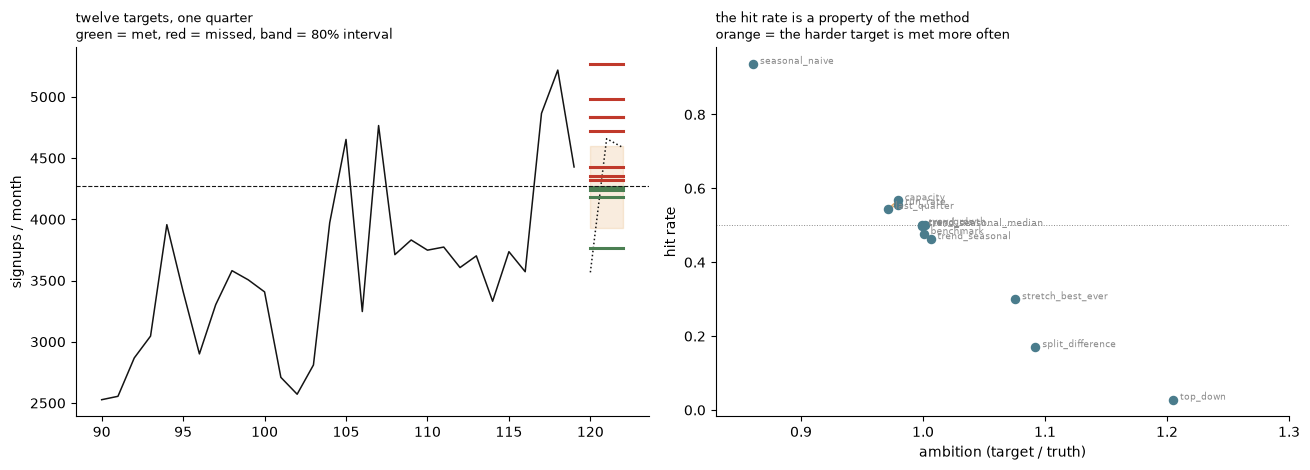

In [13]:
import matplotlib.pyplot as plt

INK, MUTED, ORANGE, GREEN, RED = "#141414", "#8a8a8a", "#d98324", "#4b7f52", "#c0392b"
fig, ax = plt.subplots(1, 2, figsize=(13.2, 4.8))

lo_m = ORIGIN - 30
ax[0].plot(np.arange(lo_m, ORIGIN), series[lo_m:ORIGIN], color=INK, lw=1.1)
ax[0].plot(np.arange(ORIGIN, ORIGIN + HORIZON),
           series[ORIGIN:ORIGIN + HORIZON], color=INK, lw=1.1, ls=":")
x = ORIGIN + np.array([0.0, HORIZON - 1])
ax[0].fill_between(x, lo_pi / HORIZON, hi_pi / HORIZON, color=ORANGE, alpha=0.15)
for nm, v in tg.items():
    met = actual >= v
    ax[0].plot(x, [v / HORIZON] * 2, color=GREEN if met else RED, lw=2.2)
ax[0].axhline(actual / HORIZON, color=INK, lw=0.8, ls="--")
ax[0].set_title("twelve targets, one quarter\ngreen = met, red = missed, band = 80% interval",
                loc="left", fontsize=9)
ax[0].set_ylabel("signups / month")

for i, j in itertools.combinations(range(len(names)), 2):
    if (amb[i] - amb[j]) * (hit[i] - hit[j]) > 0:
        ax[1].plot(amb[[i, j]], hit[[i, j]], color=ORANGE, lw=1.0, alpha=0.7)
ax[1].scatter(amb, hit, s=34, color="#4a7c8c", zorder=3)
for nm, a, h in zip(names, amb, hit):
    ax[1].annotate(nm, (a, h), fontsize=6.2, xytext=(5, 0),
                   textcoords="offset points", color=MUTED)
ax[1].axhline(0.5, color=MUTED, lw=0.7, ls=":")
ax[1].set_xlim(0.83, 1.30)
ax[1].set_xlabel("ambition (target / truth)")
ax[1].set_ylabel("hit rate")
ax[1].set_title("the hit rate is a property of the method\norange = the harder target is met more often",
                loc="left", fontsize=9)
for a_ in ax:
    a_.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## What a target is

A target is **a method plus a claim about the future**. On this history the
method moves the number by more than the business does, and the statistic used
to grade the result - the hit rate - is a property of the method that was
chosen, not of the work that was done.

Three things travel with a defensible target, and a single number carries none
of them:

1. **the method** - which of the twelve sentences produced it, written down
2. **the claim** - what it assumes about growth, seasonality and resourcing
3. **the interval** - because 52 of the 66 disagreements in that meeting are
   smaller than the uncertainty everybody is arguing inside

And one thing to stop doing: grading a team on a hit rate. It takes 134 quarters
to tell a 0.50 hitter from a 0.65 hitter, and no company has 33 years.

## Try your own

Uncomment and edit. The engine cell above is the whole implementation, so any
of it can be changed in place.

In [14]:
# --- 1. Your own target-setting method ------------------------------------
# def m_house_rule(hist, origin):
#     """Whatever your planning deck actually does."""
#     return float(hist[-12:-12 + HORIZON].sum() * 1.15)
#
# METHODS["house_rule"] = m_house_rule
# PROVENANCE["house_rule"] = "last year's quarter + 15%"
# mine = multipath(150, 999)["house_rule"]
# print(f"ambition {mine['ambition'].mean():.3f}  "
#       f"hit rate {mine['hit_rate'].mean():.3f} "
#       f"(sd {mine['hit_rate'].std():.3f})")

# --- 2. A noisier or flatter world ----------------------------------------
# SIGMA = 0.25      # a metric that moves a lot month to month
# G = 0.004         # a business that is barely growing
# s2 = make_history(seed=7)
# print({k: round(v) for k, v in targets_at(s2, 120).items()})

# --- 3. What would the board have to pay for the stretch target? ----------
# p_real = mp["trend_seasonal"]["hit_rate"].mean()
# for nm in METHODS:
#     p = mp[nm]["hit_rate"].mean()
#     if p > 0:
#         print(f"{nm:24} {p_real / p:6.2f}x payout to match trend_seasonal")

---

**Day 159 of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** - one small,
finished data tool a day.

The Streamlit version puts the world on sliders - noise, real growth, seasonal
amplitude, the board multiple, the hiring plan - and re-runs the hit rates live:

```bash
pip install -r requirements.txt
streamlit run app.py
```

`python evidence.py` prints the full ten-section audit.
`pytest test_targets.py` asserts every number in it.